In [ ]:
import math
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

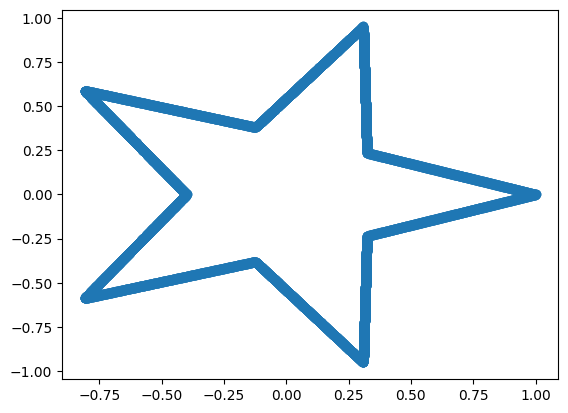

In [ ]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=5000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes
    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius
        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])
    vertices = np.array(vertices)
    sampled_points = []
    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]
        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)
    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [80]:
class VPConfig:
    def __init__(self,
                 schedule: str = 'linear',
                 beta_min: float = 0.1,
                 beta_max: float = 5.0,
                 cosine_s: float = 0.008,
                 lr: float = 1e-3,
                 epochs: int = 2000,
                 batch_size: int = 512,
                 hidden_dim: int = 256,
                 num_timesteps: int = 1000,
                 data_samples: int = 5000):
        self.schedule = schedule
        self.beta_min = beta_min
        self.beta_max = beta_max
        self.cosine_s = cosine_s
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.hidden_dim = hidden_dim
        self.num_timesteps = num_timesteps
        self.data_samples = data_samples

In [92]:
class ScoreModel(nn.Module):
    def __init__(self, config: VPConfig):
        super().__init__()
        self.config = config
        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )
        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.net(x_input)

In [93]:
def get_beta_alpha_sigma(t: torch.Tensor, config: VPConfig) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    if config.schedule == 'linear':
        beta = config.beta_min + t * (config.beta_max - config.beta_min)
        int_beta = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t**2
        alpha = torch.exp(-0.5 * int_beta)
        sigma = torch.sqrt(1.0 - alpha**2 + 1e-8)
    elif config.schedule == 'cosine':
        s = config.cosine_s
        alpha = torch.cos(math.pi / 2 * (t + s) / (1 + s))
        alpha = torch.clamp(alpha, min=0.001, max=1.0)
        sigma = torch.sqrt(1.0 - alpha**2 + 1e-8)
        beta = (math.pi / (1 + s)) * torch.tan(math.pi / 2 * (t + s) / (1 + s))
        beta = torch.clamp(beta, min=0.0, max=config.beta_max)
    else:
        raise ValueError("schedule must be 'linear' or 'cosine'")
    return beta, alpha, sigma

In [94]:
class VPTrainer:
    def __init__(self, config: VPConfig, weighting: str = 'const'):
        self.config = config
        self.weighting = weighting
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        print(f"Using device: {self.device}")

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)
        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

        self.data_mean = self.data.mean(dim=0)
        self.data_std = self.data.std(dim=0)

    def denormalize(self, samples: np.ndarray) -> np.ndarray:
        return samples * (self.data_std.cpu().numpy() + 1e-8) + self.data_mean.cpu().numpy()


    def _get_weight(self, t: torch.Tensor, alpha: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
        if self.weighting == 'const':
            return torch.ones_like(t)
        elif self.weighting == 'sigma2':
            return 1.0 / (sigma**2 + 1e-8)
        elif self.weighting == 'snr':
            return (sigma**2) / (alpha**2 + 1e-8)
        elif self.weighting == 'g2':
            beta, _, _ = get_beta_alpha_sigma(t, self.config)
            return beta
        else:
            raise ValueError(f"Unknown weighting: {self.weighting}")

    def train_epoch(self) -> float:
        self.model.train()
        total_loss = 0.0
        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            _, alpha, sigma = get_beta_alpha_sigma(t, self.config)
            noise = torch.randn_like(batch)
            x_t = alpha * batch + sigma * noise
            pred_noise = self.model(x_t, t)
            weights = self._get_weight(t, alpha, sigma)
            loss = (weights * ((pred_noise - noise) ** 2).mean(dim=1)).mean()

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self, verbose=True):
        for epoch in range(self.config.epochs):
            loss = self.train_epoch()
            if verbose and epoch % 200 == 0:
                print(f"[{self.config.schedule}, w={self.weighting}] Epoch {epoch:4d} Loss: {loss:.4f}")

In [95]:
def sample_vp_sde(model: ScoreModel, config: VPConfig, num_samples: int = 1000) -> np.ndarray:
    device = next(model.parameters()).device
    model.eval()

    x = torch.randn(num_samples, 2, device=device)
    dt = 1.0 / config.num_timesteps

    with torch.no_grad():
        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t_tensor = torch.full((num_samples, 1), t, device=device)

            _, alpha, sigma = get_beta_alpha_sigma(t_tensor, config)
            pred_noise = model(x, t_tensor)
            pred_x0 = (x - sigma * pred_noise) / (alpha + 1e-8)

            t_prev = max(0.0, t - dt)
            t_prev_tensor = torch.full((num_samples, 1), t_prev, device=device)
            _, alpha_prev, sigma_prev = get_beta_alpha_sigma(t_prev_tensor, config)
            x = alpha_prev * pred_x0 + sigma_prev * torch.randn_like(x)

    return x.cpu().numpy()


--- Training linear schedule, weighting=const ---
Using device: cuda
  Epoch    0, Loss: 0.9147
  Epoch  200, Loss: 0.3320
  Epoch  400, Loss: 0.3474
  Epoch  600, Loss: 0.3197

--- Training linear schedule, weighting=sigma2 ---
Using device: cuda
  Epoch    0, Loss: 46.1254
  Epoch  200, Loss: 30.1881
  Epoch  400, Loss: 154.4538
  Epoch  600, Loss: 30.1500

--- Training linear schedule, weighting=g2 ---
Using device: cuda
  Epoch    0, Loss: 2.3782
  Epoch  200, Loss: 0.8515
  Epoch  400, Loss: 0.8492
  Epoch  600, Loss: 0.7687

--- Training linear schedule, weighting=snr ---
Using device: cuda
  Epoch    0, Loss: 2.0638
  Epoch  200, Loss: 0.7781
  Epoch  400, Loss: 0.7714
  Epoch  600, Loss: 0.6977

--- Training cosine schedule, weighting=const ---
Using device: cuda
  Epoch    0, Loss: 0.8862
  Epoch  200, Loss: 0.3374
  Epoch  400, Loss: 0.3229
  Epoch  600, Loss: 0.2953

--- Training cosine schedule, weighting=sigma2 ---
Using device: cuda
  Epoch    0, Loss: 46.8174
  Epoch  2

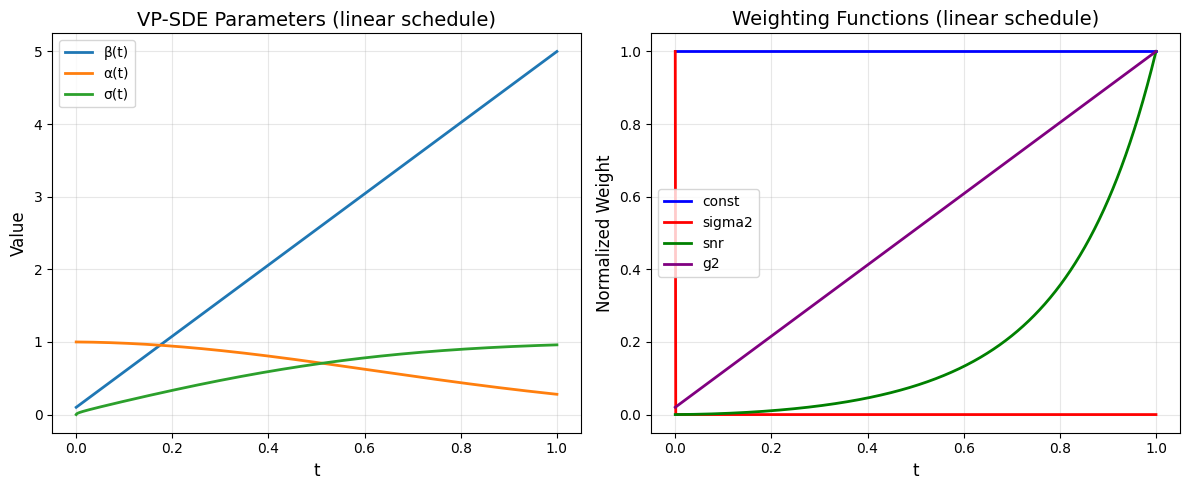

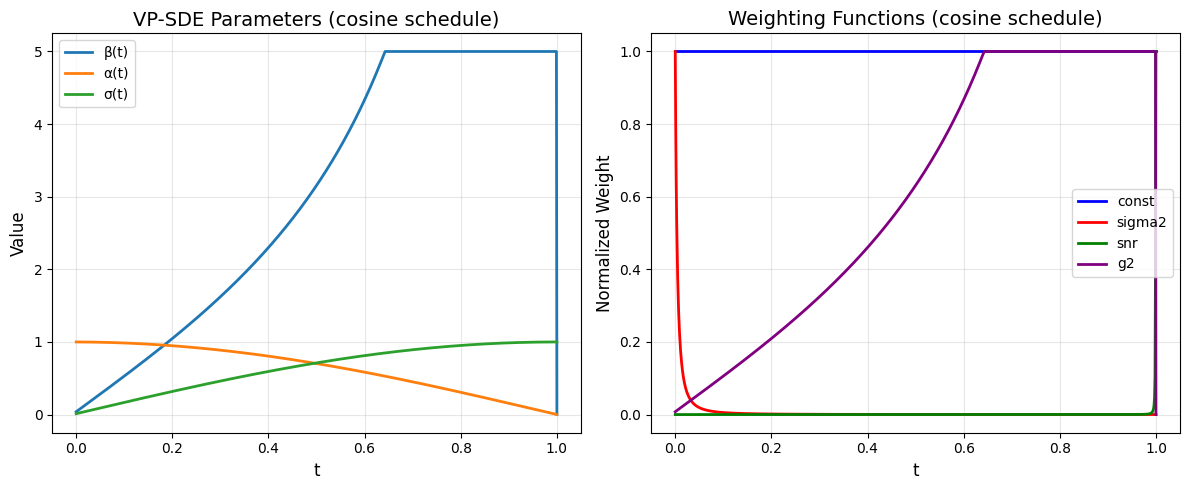

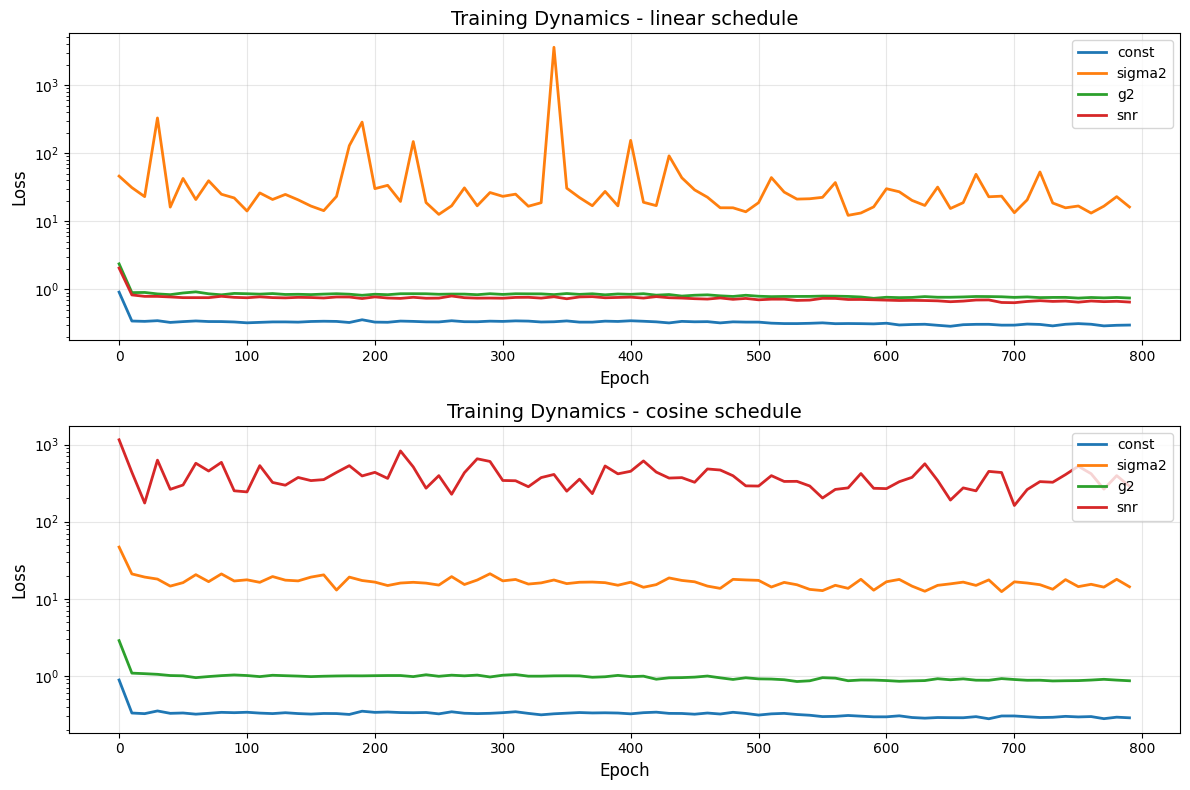

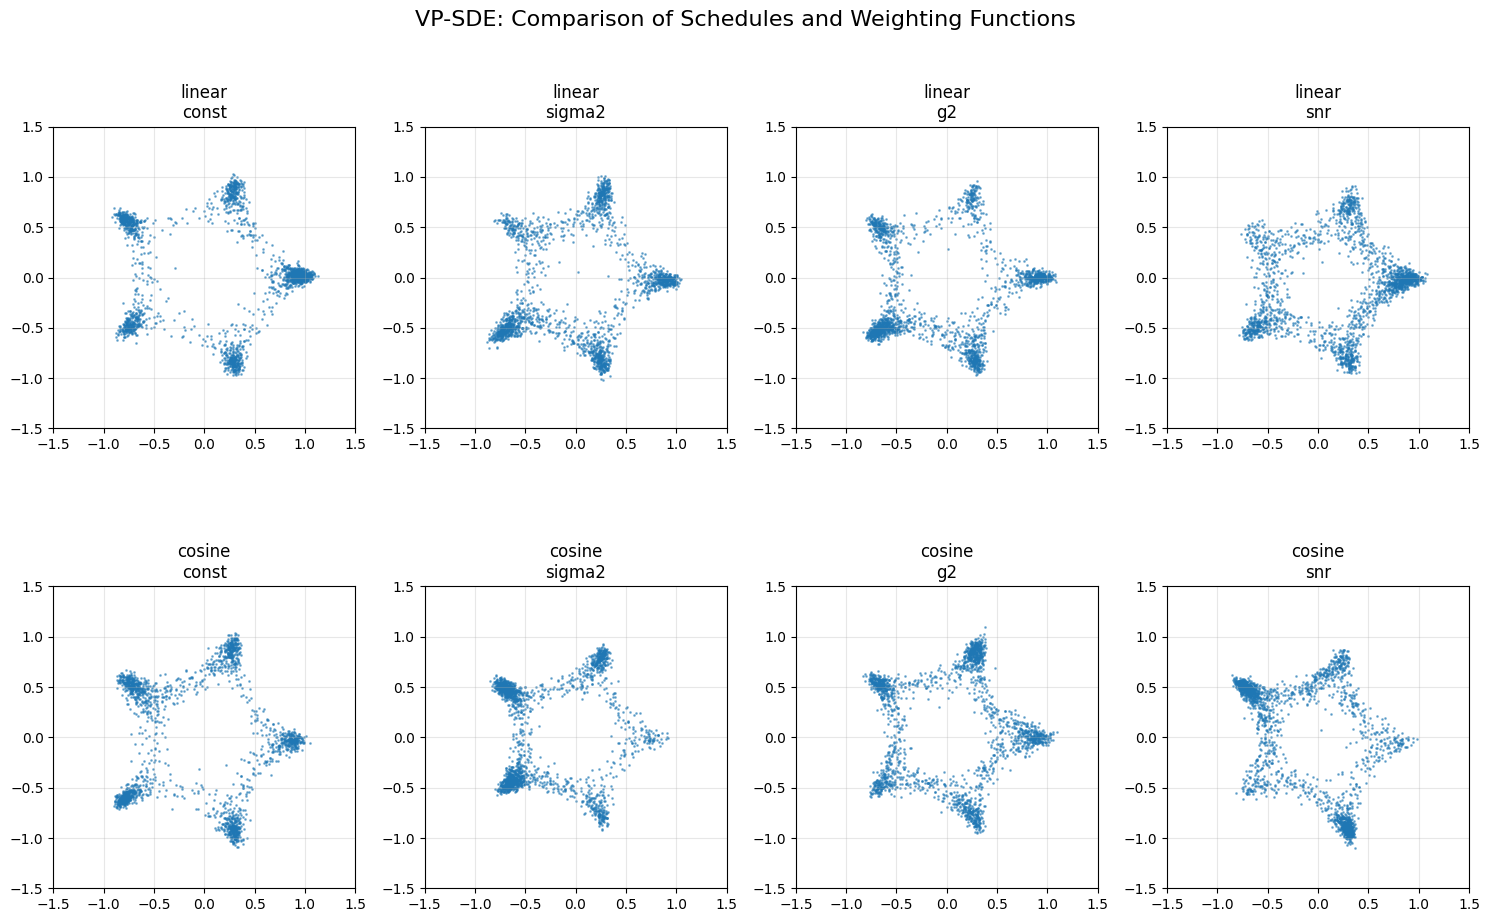

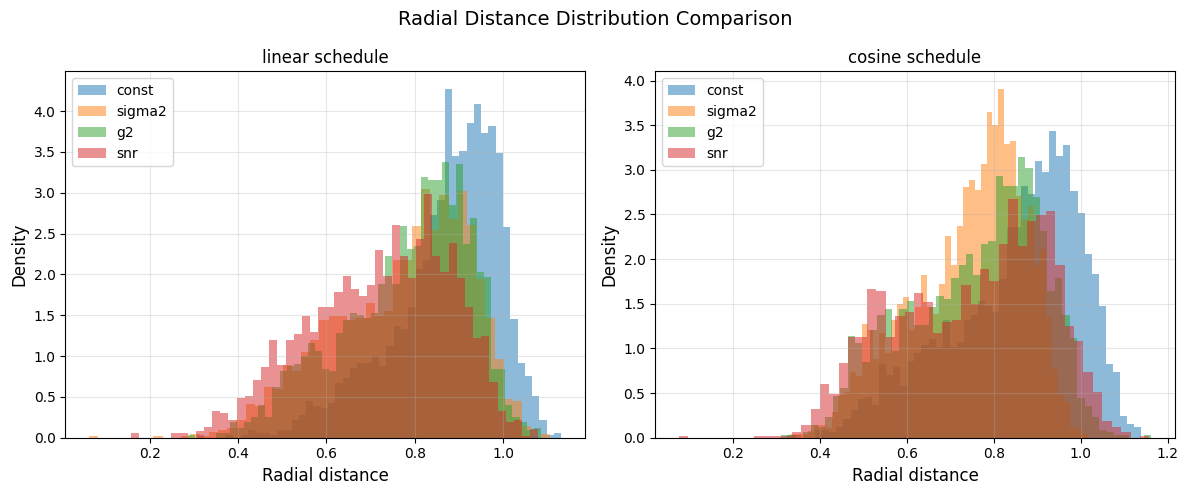

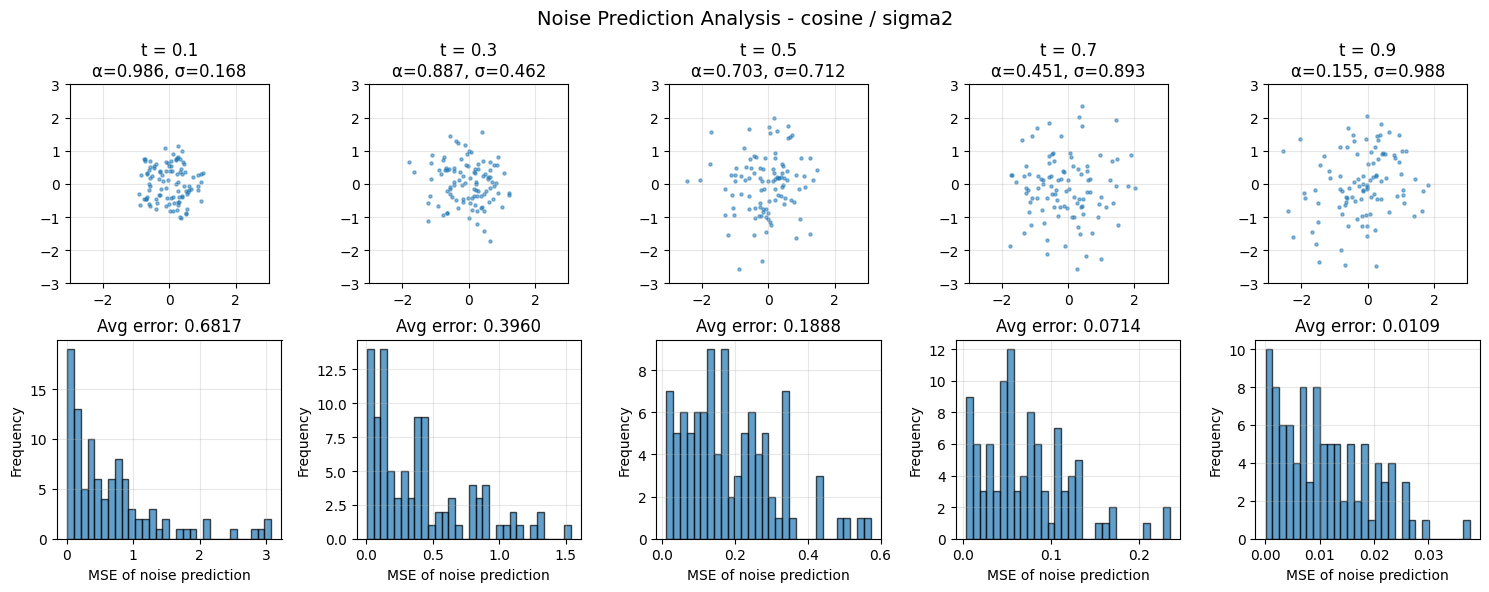


LINEAR schedule:
  const   : mean=0.873, std=0.122, cv=0.139
  sigma2  : mean=0.771, std=0.152, cv=0.198
  g2      : mean=0.782, std=0.142, cv=0.182
  snr     : mean=0.723, std=0.158, cv=0.218

COSINE schedule:
  const   : mean=0.849, std=0.151, cv=0.178
  sigma2  : mean=0.741, std=0.129, cv=0.174
  g2      : mean=0.757, std=0.151, cv=0.200
  snr     : mean=0.750, std=0.173, cv=0.230


In [96]:
def run_complete_analysis():
    schedules = ['linear', 'cosine']
    weightings = ['const', 'sigma2', 'g2', 'snr']

    results = {}
    training_losses = {}
    trained_models = {}
    for sched in schedules:
        for w in weightings:
            print(f"\n--- Training {sched} schedule, weighting={w} ---")
            cfg = VPConfig(
                schedule=sched,
                epochs=800,
                num_timesteps=500,
                batch_size=512,
                hidden_dim=256
            )

            trainer = VPTrainer(cfg, weighting=w)

            losses = []
            for epoch in range(cfg.epochs):
                loss = trainer.train_epoch()
                if epoch % 10 == 0:
                    losses.append((epoch, loss))
                if epoch % 200 == 0:
                    print(f"  Epoch {epoch:4d}, Loss: {loss:.4f}")

            training_losses[(sched, w)] = losses
            samples = sample_vp_sde(trainer.model, cfg, num_samples=2000)
            results[(sched, w)] = samples
            trained_models[(sched, w)] = trainer.model
    for sched in schedules:
        cfg = VPConfig(schedule=sched)
        visualize_weighting_functions(cfg)
    fig, axes = plt.subplots(len(schedules), 1, figsize=(12, 8))
    if len(schedules) == 1:
        axes = [axes]

    for idx, sched in enumerate(schedules):
        for w in weightings:
            epochs, losses = zip(*training_losses[(sched, w)])
            axes[idx].plot(epochs, losses, label=w, linewidth=2)

        axes[idx].set_xlabel('Epoch', fontsize=12)
        axes[idx].set_ylabel('Loss', fontsize=12)
        axes[idx].set_title(f'Training Dynamics - {sched} schedule', fontsize=14)
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_yscale('log')

    plt.tight_layout()
    plt.show()
    fig = plt.figure(figsize=(15, 10))
    fig.suptitle('VP-SDE: Comparison of Schedules and Weighting Functions', fontsize=16)

    for i, sched in enumerate(schedules):
        for j, w in enumerate(weightings):
            ax = plt.subplot(len(schedules), len(weightings), i * len(weightings) + j + 1)
            samples = results[(sched, w)]
            ax.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.5)
            ax.set_title(f'{sched}\n{w}', fontsize=12)
            ax.set_xlim(-1.5, 1.5)
            ax.set_ylim(-1.5, 1.5)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Radial Distance Distribution Comparison', fontsize=14)

    for idx, sched in enumerate(schedules):
        ax = axes[idx]
        for w in weightings:
            samples = results[(sched, w)]
            radii = np.sqrt(samples[:, 0]**2 + samples[:, 1]**2)
            ax.hist(radii, bins=50, alpha=0.5, label=w, density=True)
        ax.set_xlabel('Radial distance', fontsize=12)
        ax.set_ylabel('Density', fontsize=12)
        ax.set_title(f'{sched} schedule', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    best_sched = 'cosine'
    best_weight = 'sigma2'

    if (best_sched, best_weight) in trained_models:
        cfg = VPConfig(schedule=best_sched)
        visualize_noise_levels(trained_models[(best_sched, best_weight)], cfg, best_weight)

    for sched in schedules:
        print(f"\n{sched.upper()} schedule:")
        for w in weightings:
            samples = results[(sched, w)]
            radii = np.sqrt(samples[:, 0]**2 + samples[:, 1]**2)
            expected_radii = np.array([0.4, 1.0])
            mean_radius = radii.mean()
            std_radius = radii.std()
            radius_std_ratio = std_radius / mean_radius

            print(f"  {w:8s}: mean={mean_radius:.3f}, std={std_radius:.3f}, cv={radius_std_ratio:.3f}")

    return results, training_losses, trained_models

def visualize_weighting_functions(config: VPConfig):
    t_values = torch.linspace(0, 1, 1000)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    betas = []
    alphas = []
    sigmas = []

    for t in t_values:
        beta, alpha, sigma = get_beta_alpha_sigma(t.unsqueeze(0), config)
        betas.append(beta.item())
        alphas.append(alpha.item())
        sigmas.append(sigma.item())

    plt.plot(t_values.numpy(), betas, label='β(t)', linewidth=2)
    plt.plot(t_values.numpy(), alphas, label='α(t)', linewidth=2)
    plt.plot(t_values.numpy(), sigmas, label='σ(t)', linewidth=2)
    plt.xlabel('t', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.title(f'VP-SDE Parameters ({config.schedule} schedule)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)

    weightings = ['const', 'sigma2', 'snr', 'g2']
    colors = ['blue', 'red', 'green', 'purple']

    for weighting, color in zip(weightings, colors):
        weights = []
        for t in t_values:
            _, alpha, sigma = get_beta_alpha_sigma(t.unsqueeze(0), config)

            if weighting == 'const':
                w = 1.0
                weights.append(w)
                continue
            elif weighting == 'sigma2':
                w = 1.0 / (sigma**2 + 1e-8)
            elif weighting == 'snr':
                w = (sigma**2) / (alpha**2 + 1e-8)
            elif weighting == 'g2':
                beta, _, _ = get_beta_alpha_sigma(t.unsqueeze(0), config)
                w = beta
            else:
                w = 1.0

            weights.append(w.item() if hasattr(w, 'item') else w)
        weights = np.array(weights)
        weights = weights / (weights.max() + 1e-8)

        plt.plot(t_values.numpy(), weights, label=weighting, color=color, linewidth=2)

    plt.xlabel('t', fontsize=12)
    plt.ylabel('Normalized Weight', fontsize=12)
    plt.title(f'Weighting Functions ({config.schedule} schedule)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def visualize_noise_levels(model, config: VPConfig, weighting: str, num_samples: int = 100):
    device = next(model.parameters()).device
    model.eval()

    star = generate_star(n_samples=num_samples)
    data = torch.tensor(star, dtype=torch.float32).to(device)

    t_levels = [0.1, 0.3, 0.5, 0.7, 0.9]

    fig, axes = plt.subplots(2, len(t_levels), figsize=(15, 6))
    fig.suptitle(f'Noise Prediction Analysis - {config.schedule} / {weighting}', fontsize=14)

    for i, t_val in enumerate(t_levels):
        t = torch.full((num_samples, 1), t_val, device=device)
        _, alpha, sigma = get_beta_alpha_sigma(t, config)

        real_noise = torch.randn_like(data)
        x_t = alpha * data + sigma * real_noise

        with torch.no_grad():
            pred_noise = model(x_t, t)

        ax1 = axes[0, i]
        ax1.scatter(x_t.cpu()[:, 0], x_t.cpu()[:, 1], s=5, alpha=0.5)
        ax1.set_title(f't = {t_val}\nα={alpha[0,0]:.3f}, σ={sigma[0,0]:.3f}')
        ax1.set_xlim(-3, 3)
        ax1.set_ylim(-3, 3)
        ax1.set_aspect('equal')
        ax1.grid(True, alpha=0.3)

        ax2 = axes[1, i]
        noise_error = ((pred_noise - real_noise) ** 2).mean(dim=1).cpu().numpy()
        ax2.hist(noise_error, bins=30, alpha=0.7, edgecolor='black')
        ax2.set_xlabel('MSE of noise prediction')
        ax2.set_ylabel('Frequency')
        ax2.set_title(f'Avg error: {noise_error.mean():.4f}')
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'noise_analysis_{config.schedule}_{weighting}.png', dpi=150, bbox_inches='tight')
    plt.show()

results, losses, models = run_complete_analysis()